### GPK 1.1 - Mouna Loua Observatory Data

This task is based on Section 5.4.3 of “Gaussian Processes for Machine Learning” by Rasmussen. It illustrates an example of complex kernel engineering and hyperparameter optimization using gradient ascent on the log-marginal-likelihood. The data consists of the monthly average atmospheric CO2 concentrations (in parts per million by volume (ppm)) collected at the Mauna Loa Observatory in Hawaii, between 1958 and 2024. The objective is to model the CO2 concentration as a function of the time and extrapolate for years after 2024.

In [25]:
# Load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data = pd.read_csv("co2_mm_mlo.csv")

In [26]:
data['Date'] = pd.to_datetime(data[['year', 'month']].assign(day=1))
data.set_index('Date', inplace=True)

In [27]:
data.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
Date,,,,,,,,
1958-03-01,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1958-04-01,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
1958-05-01,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
1958-06-01,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
1958-07-01,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


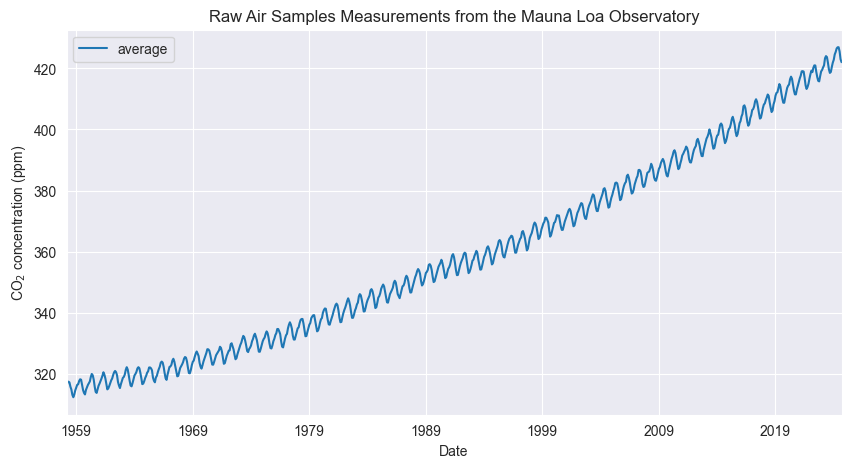

In [28]:
# Plot with Date on x-axis
data.plot(y='average', figsize=(10, 5), legend=True)
plt.xlabel("Date")
plt.ylabel("CO$_2$ concentration (ppm)")
plt.title("Raw Air Samples Measurements from the Mauna Loa Observatory")
plt.show()

In [29]:
y = data['average'].values
X = np.arange(len(y)).reshape(-1, 1)  # Using time index as feature
# Split data
X_train, y_train = X[:int(len(X)*0.9)], y[:int(len(y)*0.9)]
X_test, y_test = X[int(len(X)*0.9):], y[int(len(y)*0.9):]

The idea in this exercise will be to predict the CO2 concentration in function of the date.

In [30]:
y_mean = y_train.mean()

#### Design the proper kernel

To design the kernel to use with our Gaussian process, we can make some assumption regarding the data at hand. We observe that they have several characteristics: we see a long term rising trend, a pronounced seasonal variation and some smaller irregularities. We can use different appropriate kernel that would capture these features.

**Task 1a**: Fit the long term rising trend by using a radial basis function (RBF) kernel with a large length-scale parameter. The RBF kernel with a large length-scale enforces this component to be smooth. The specific length-scale and the amplitude are free hyperparameters.

In [31]:
from sklearn.gaussian_process.kernels import RBF

long_term_trend_kernel = 50.0**2 * RBF(length_scale=50.0)
co2_kernel = (
    long_term_trend_kernel)
co2_kernel

50**2 * RBF(length_scale=50)

In [32]:
from sklearn.gaussian_process import GaussianProcessRegressor
gaussian_process = GaussianProcessRegressor(kernel=co2_kernel, normalize_y=False, n_restarts_optimizer=10)
gaussian_process.fit(X_train, y_train - y_mean)

y_train_pred, y_train_std = gaussian_process.predict(X_train, return_std=True)
y_test_pred, y_test_std = gaussian_process.predict(X_test, return_std=True)
y_train_pred += y_mean
y_test_pred += y_mean

/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


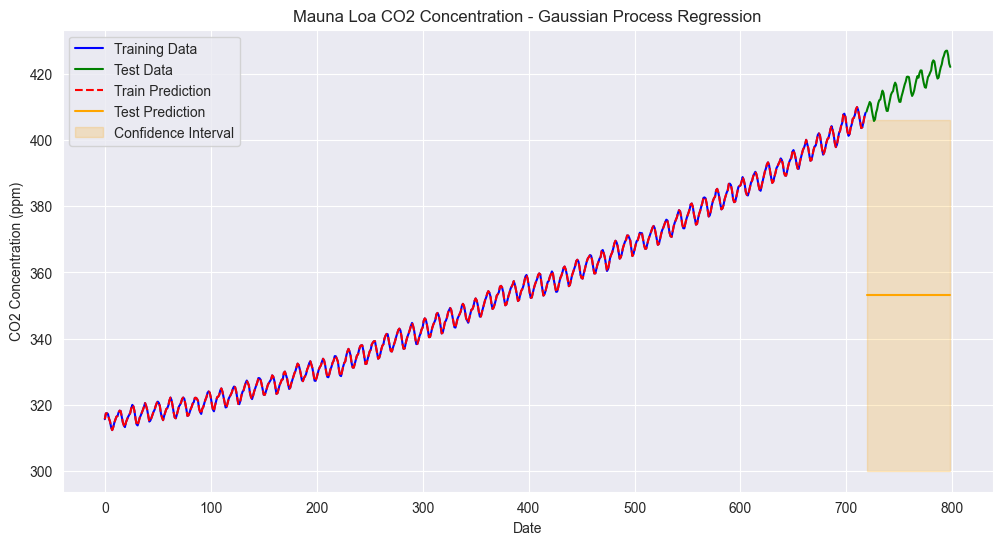

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(X_train, y_train, 'b-', label="Training Data")
plt.plot(X_test, y_test, 'g-', label="Test Data")
plt.plot(X_train, y_train_pred, 'r--', label="Train Prediction")
plt.plot(X_test, y_test_pred, 'orange', label="Test Prediction")
plt.fill_between(X_test.flatten(),
                 y_test_pred - 1.96 * y_test_std,
                 y_test_pred + 1.96 * y_test_std,
                 color='orange', alpha=0.2, label="Confidence Interval")
plt.legend()
plt.xlabel("Date")
plt.ylabel("CO2 Concentration (ppm)")
plt.title("Mauna Loa CO2 Concentration - Gaussian Process Regression")
plt.show()

**Task 1b**: Fit the seasonal variation by means of the periodic exponential sine squared kernel with a fixed periodicity of 12 months. The length-scale of this periodic component, controlling its smoothness, is a free parameter. In order to allow decaying away from exact periodicity, the sine squared kernel is combined  with an RBF kernel. The length-scale of this RBF component controls the decay time and is a further free parameter. This type of kernel is also known as locally periodic kernel.

In [34]:
from sklearn.gaussian_process.kernels import ExpSineSquared

seasonal_kernel = (
    2.0**2
    * RBF(length_scale=100.0)
    * ExpSineSquared(length_scale=1.0, periodicity=12.0, periodicity_bounds="fixed")
)

In [35]:
co2_kernel = (
    long_term_trend_kernel + seasonal_kernel
)
co2_kernel

50**2 * RBF(length_scale=50) + 2**2 * RBF(length_scale=100) * ExpSineSquared(length_scale=1, periodicity=12)

In [36]:
from sklearn.gaussian_process import GaussianProcessRegressor
gaussian_process = GaussianProcessRegressor(kernel=co2_kernel, normalize_y=False, n_restarts_optimizer=10)
gaussian_process.fit(X_train, y_train - y_mean)

y_train_pred, y_train_std = gaussian_process.predict(X_train, return_std=True)
y_test_pred, y_test_std = gaussian_process.predict(X_test, return_std=True)
y_train_pred += y_mean
y_test_pred += y_mean

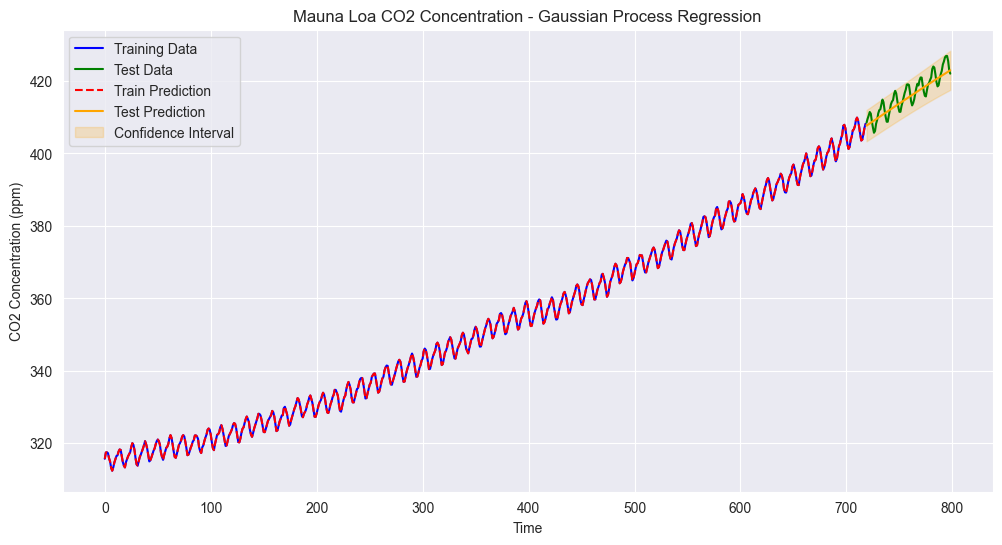

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(X_train, y_train, 'b-', label="Training Data")
plt.plot(X_test, y_test, 'g-', label="Test Data")
plt.plot(X_train, y_train_pred, 'r--', label="Train Prediction")
plt.plot(X_test, y_test_pred, 'orange', label="Test Prediction")
plt.fill_between(X_test.flatten(),
                 y_test_pred - 1.96 * y_test_std,
                 y_test_pred + 1.96 * y_test_std,
                 color='orange', alpha=0.2, label="Confidence Interval")
plt.legend()
plt.xlabel("Time")
plt.ylabel("CO2 Concentration (ppm)")
plt.title("Mauna Loa CO2 Concentration - Gaussian Process Regression")
plt.show()

**Task 1c**: Fit the small irregularities by means of a rational quadratic kernel component. The length-scale and alpha parameter of the quadratic kernel quantifies the diffuseness of the length-scales and need to be determined. A rational quadratic kernel is equivalent to an RBF kernel with several length-scales and will better accommodate different irregularities.

In [38]:
from sklearn.gaussian_process.kernels import RationalQuadratic

irregularities_kernel = 0.5**2 * RationalQuadratic(length_scale=1.0, alpha=1.0)

In [39]:
co2_kernel = (
    long_term_trend_kernel + seasonal_kernel + irregularities_kernel
)
co2_kernel

50**2 * RBF(length_scale=50) + 2**2 * RBF(length_scale=100) * ExpSineSquared(length_scale=1, periodicity=12) + 0.5**2 * RationalQuadratic(alpha=1, length_scale=1)

In [40]:
gaussian_process = GaussianProcessRegressor(kernel=co2_kernel, normalize_y=False, n_restarts_optimizer=10)
gaussian_process.fit(X_train, y_train - y_mean)
y_train_pred, y_train_std = gaussian_process.predict(X_train, return_std=True)
y_test_pred, y_test_std = gaussian_process.predict(X_test, return_std=True)
y_train_pred += y_mean
y_test_pred += y_mean

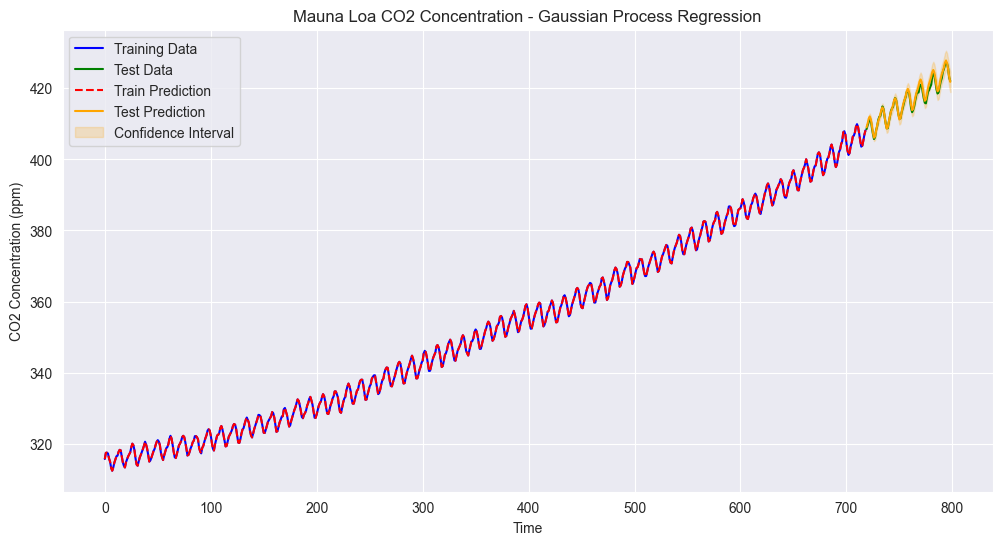

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(X_train, y_train, 'b-', label="Training Data")
plt.plot(X_test, y_test, 'g-', label="Test Data")
plt.plot(X_train, y_train_pred, 'r--', label="Train Prediction")
plt.plot(X_test, y_test_pred, 'orange', label="Test Prediction")
plt.fill_between(X_test.flatten(),
                 y_test_pred - 1.96 * y_test_std,
                 y_test_pred + 1.96 * y_test_std,
                 color='orange', alpha=0.2, label="Confidence Interval")
plt.legend()
plt.xlabel("Time")
plt.ylabel("CO2 Concentration (ppm)")
plt.title("Mauna Loa CO2 Concentration - Gaussian Process Regression")
plt.show()

**Task 1d**: Fit the noise in the dataset by means of a kernel consisting of an RBF kernel contribution, which shall explain the correlated noise components such as local weather phenomena, and a white kernel contribution for the white noise. The relative amplitudes and the RBF’s length scale are further free parameters.

In [42]:
from sklearn.gaussian_process.kernels import WhiteKernel

noise_kernel = 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(
    noise_level=0.1**2, noise_level_bounds=(1e-5, 1e5)
)

In [43]:
co2_kernel = (
    long_term_trend_kernel + seasonal_kernel + irregularities_kernel + noise_kernel
)
co2_kernel


50**2 * RBF(length_scale=50) + 2**2 * RBF(length_scale=100) * ExpSineSquared(length_scale=1, periodicity=12) + 0.5**2 * RationalQuadratic(alpha=1, length_scale=1) + 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.01)

In [44]:
gaussian_process = GaussianProcessRegressor(kernel=co2_kernel, normalize_y=False, n_restarts_optimizer=10)
gaussian_process.fit(X_train, y_train - y_mean)
y_train_pred, y_train_std = gaussian_process.predict(X_train, return_std=True)
y_test_pred, y_test_std = gaussian_process.predict(X_test, return_std=True)
y_train_pred += y_mean
y_test_pred += y_mean

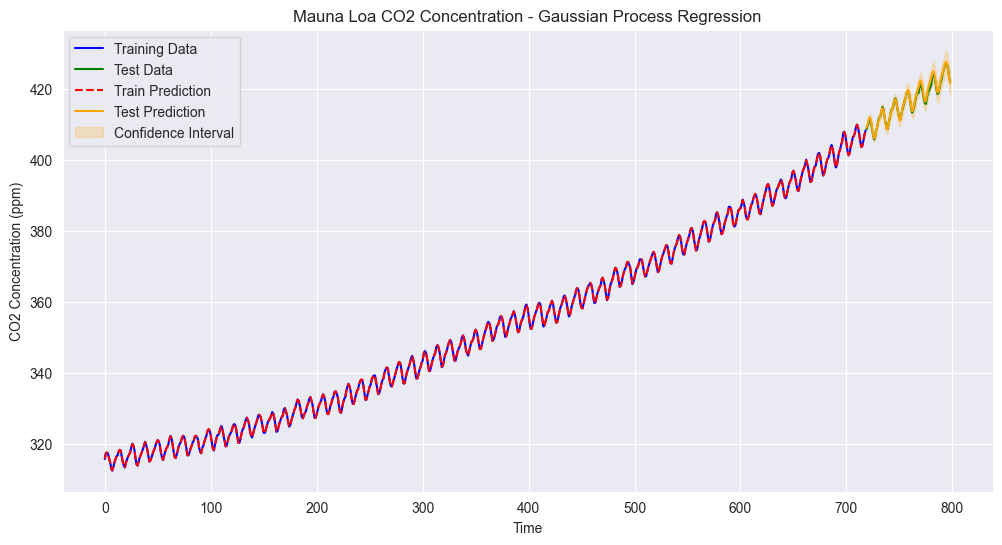

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(X_train, y_train, 'b-', label="Training Data")
plt.plot(X_test, y_test, 'g-', label="Test Data")
plt.plot(X_train, y_train_pred, 'r--', label="Train Prediction")
plt.plot(X_test, y_test_pred, 'orange', label="Test Prediction")
plt.fill_between(X_test.flatten(),
                 y_test_pred - 1.96 * y_test_std,
                 y_test_pred + 1.96 * y_test_std,
                 color='orange', alpha=0.2, label="Confidence Interval")
plt.legend()
plt.xlabel("Time")
plt.ylabel("CO2 Concentration (ppm)")
plt.title("Mauna Loa CO2 Concentration - Gaussian Process Regression")
plt.show()

**Task 1e**: Compute the mean squared error on the train and test set. In addition, compute negative log predictive density (NLPD) on the train and test set.

In [46]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_train, y_train_pred)

print(f"Train Mean Squared Error (MSE): {mse}")


Train Mean Squared Error (MSE): 0.006806396335239132


In [47]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_test_pred)
# Calculate NLPD
nlpd = 0.5 * np.sum((y_test - y_test_pred)**2 / (y_test_std**2) + 0.5 * np.log(2 * np.pi * y_test_std**2))

print(f"Test Mean Squared Error (MSE): {mse}")
print(f"negative log predictive density (NLPD): {nlpd}")

Test Mean Squared Error (MSE): 0.3893538811509848
negative log predictive density (NLPD): 51.753008047648606
